# NeuroTalk Transfer Learning for EEG-to-Mel Spectrogram

هذا النوتبوك يعيد كتابة الكود الأصلي باستخدام بنية **NeuroTalk** (AAAI 2023) كـ Transfer Learning.

### NeuroTalk Architecture (Lee et al., AAAI 2023)
- **Multi-Receptive Residual Blocks**: Conv1d بأحجام kernels مختلفة (3, 5, 7) لاستخراج الخصائص الترددية
- **Bidirectional GRU**: لاستخراج المعلومات التسلسلية
- **Transposed Conv1d**: لرفع الدقة الزمنية إلى حجم Mel-spectrogram

### Transfer Learning Strategy
1. بناء backbone مبني على NeuroTalk Generator
2. إضافة Input Adapter لتحويل 127 قناة EEG إلى الأبعاد المطلوبة
3. إضافة Subject Embedding لدعم عدة أشخاص
4. **Phase 1**: تجميد backbone وتدريب الطبقات الجديدة فقط
5. **Phase 2**: فتح الـ backbone للتدريب الكامل (fine-tuning)

**Reference:**
> Y.-E. Lee, S.-H. Lee, S.-H Kim, and S.-W. Lee, "Towards Voice Reconstruction from EEG during Imagined Speech," AAAI 2023.
> GitHub: https://github.com/youngeun1209/NeuroTalk

In [1]:
# ============================================================
# STEP 0: Imports + Settings + Seed
# ============================================================
import os, copy, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# --------------------
# SETTINGS
# --------------------
MANIFEST_CSV = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\manifest_pairs.csv"
ALL_SUBJECTS = ["SUB1","SUB2","SUB3","SUB4","SUB5","SUB6","SUB7","SUB8","SUB9","SUB10"]

TARGET_CH  = 127      # max EEG channels (padded)
T_FIXED    = 1349     # fixed EEG time length
MEL_BINS   = 80       # mel-spectrogram frequency bins
MEL_FRAMES = 259      # mel-spectrogram time frames

BATCH_SIZE   = 4
EPOCHS_P1    = 15     # Phase 1: backbone مجمّد
EPOCHS_P2    = 45     # Phase 2: fine-tuning كامل
PATIENCE     = 8
LR_P1        = 5e-4   # learning rate أعلى في Phase 1 (طبقات جديدة فقط)
LR_P2        = 1e-4   # learning rate أقل في Phase 2
WEIGHT_DECAY = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_NAME = "neurotalk_tl_best.pt"

# --------------------
# SEED
# --------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")

Device: cpu


In [2]:
# ============================================================
# STEP 1: Time Padding / Cropping Functions
# ============================================================
def pad_or_crop_time(x, T_fixed=T_FIXED):
    """Pad (with zeros) or crop to fixed time length."""
    C, T = x.shape
    if T == T_fixed:
        return x
    if T > T_fixed:
        return x[:, :T_fixed]
    out = np.zeros((C, T_fixed), dtype=x.dtype)
    out[:, :T] = x
    return out

def center_crop_time(x, T_fixed=T_FIXED):
    """Center crop for validation/test."""
    C, T = x.shape
    if T <= T_fixed:
        return pad_or_crop_time(x, T_fixed)
    start = (T - T_fixed) // 2
    return x[:, start:start + T_fixed]

def random_crop_time(x, T_fixed=T_FIXED):
    """Random crop for training (data augmentation)."""
    C, T = x.shape
    if T <= T_fixed:
        return pad_or_crop_time(x, T_fixed)
    start = np.random.randint(0, T - T_fixed + 1)
    return x[:, start:start + T_fixed]

print("✅ Time functions defined")

✅ Time functions defined


In [3]:
# ============================================================
# STEP 2: Compute Per-Subject EEG Statistics (Mean/Std)
# ============================================================
def compute_eeg_stats_train(manifest_csv, subject):
    """Compute per-channel mean and std from training data for z-score normalization."""
    df = pd.read_csv(manifest_csv)
    df = df[(df["subject"] == subject) & (df["split"] == "train")].reset_index(drop=True)

    sum_c = None
    sumsq_c = None
    count_t = 0

    for p in df["eeg_path"].tolist():
        x = np.load(p)
        if x.shape[0] > x.shape[1]:
            x = x.T
        x = x.astype(np.float64)

        if sum_c is None:
            sum_c   = x.sum(axis=1)
            sumsq_c = (x**2).sum(axis=1)
        else:
            sum_c   += x.sum(axis=1)
            sumsq_c += (x**2).sum(axis=1)

        count_t += x.shape[1]

    mean = (sum_c / count_t).astype(np.float32)
    var  = (sumsq_c / count_t - mean.astype(np.float64)**2).astype(np.float32)
    std  = np.sqrt(np.maximum(var, 1e-8)).astype(np.float32)
    return mean, std

eeg_stats = {s: compute_eeg_stats_train(MANIFEST_CSV, s) for s in ALL_SUBJECTS}
print("✅ Computed stats for", len(eeg_stats), "subjects")

✅ Computed stats for 10 subjects


In [4]:
# ============================================================
# STEP 3: Dataset (Pad Channels + Channel Mask + Subject ID)
# ============================================================
class MultiSubjectMaskedDataset(Dataset):
    def __init__(self, manifest_csv, split, subjects, eeg_stats):
        self.df = pd.read_csv(manifest_csv)
        self.df = self.df[
            (self.df["split"] == split) & (self.df["subject"].isin(subjects))
        ].reset_index(drop=True)

        self.split    = split
        self.subjects = list(subjects)
        self.sub2idx  = {s: i for i, s in enumerate(self.subjects)}
        self.eeg_stats = eeg_stats

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        subj = row["subject"]

        # Load EEG
        eeg = np.load(row["eeg_path"])
        if eeg.shape[0] > eeg.shape[1]:
            eeg = eeg.T
        eeg = eeg.astype(np.float32)

        # Load Mel
        mel = np.load(row["mel_path"]).astype(np.float32)

        # Per-subject z-score normalization
        mean, std = self.eeg_stats[subj]
        eeg = (eeg - mean[:, None]) / (std[:, None] + 1e-8)

        # Pad channels to TARGET_CH (127)
        C, T = eeg.shape
        eeg_pad = np.zeros((TARGET_CH, T), dtype=np.float32)
        eeg_pad[:C, :] = eeg

        # Channel mask: 1 for real channels, 0 for padded
        mask = np.zeros((TARGET_CH, 1), dtype=np.float32)
        mask[:C, 0] = 1.0

        # Time handling
        if self.split == "train":
            eeg_pad = random_crop_time(eeg_pad)
        else:
            eeg_pad = center_crop_time(eeg_pad)

        sid = self.sub2idx[subj]

        return (
            torch.from_numpy(eeg_pad),
            torch.from_numpy(mel),
            torch.from_numpy(mask),
            torch.tensor(sid, dtype=torch.long)
        )

print("✅ Dataset class defined")

✅ Dataset class defined


In [5]:
# ============================================================
# STEP 4: Create DataLoaders with Balanced Sampling
# ============================================================
train_set = MultiSubjectMaskedDataset(MANIFEST_CSV, "train", ALL_SUBJECTS, eeg_stats)
val_set   = MultiSubjectMaskedDataset(MANIFEST_CSV, "val",   ALL_SUBJECTS, eeg_stats)
test_set  = MultiSubjectMaskedDataset(MANIFEST_CSV, "test",  ALL_SUBJECTS, eeg_stats)

# Balanced sampling by subject frequency
sub_counts = train_set.df["subject"].value_counts().to_dict()
weights = [1.0 / sub_counts[s] for s in train_set.df["subject"].tolist()]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)

print(f"✅ Loaders ready: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")

✅ Loaders ready: Train=796, Val=99, Test=101


In [6]:
# ============================================================
# STEP 5: NeuroTalk-Style Model Architecture
# ============================================================
# Based on: "Towards Voice Reconstruction from EEG during 
# Imagined Speech" (Lee et al., AAAI 2023)
#
# Key components from NeuroTalk Generator:
#   1) Multi-Receptive Residual Blocks (kernels 3, 5, 7)
#   2) Bidirectional GRU for sequential modeling
#   3) Transposed Conv1d for upsampling to mel-spectrogram
#
# Adaptations for our task:
#   - Input Adapter: 127-ch EEG -> intermediate features
#   - Subject Embedding for multi-subject training
#   - Output adjusted for (80 bins × 259 frames)
# ============================================================


class MultiReceptiveResBlock(nn.Module):
    """
    Multi-Receptive Residual Block (NeuroTalk core component).
    Uses parallel Conv1d with kernel sizes 3, 5, 7 to capture
    different frequency characteristics, then merges with residual.
    """
    def __init__(self, channels, use_dropout=True, dropout_rate=0.1):
        super().__init__()
        # Three parallel convolution paths with different receptive fields
        self.conv_k3 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.LeakyReLU(0.2)
        )
        self.conv_k5 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels),
            nn.LeakyReLU(0.2)
        )
        self.conv_k7 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(channels),
            nn.LeakyReLU(0.2)
        )
        # Merge the three paths
        self.merge = nn.Sequential(
            nn.Conv1d(channels * 3, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.LeakyReLU(0.2)
        )
        self.dropout = nn.Dropout(dropout_rate) if use_dropout else nn.Identity()

    def forward(self, x):
        # Parallel multi-receptive paths
        h3 = self.conv_k3(x)
        h5 = self.conv_k5(x)
        h7 = self.conv_k7(x)
        # Concatenate and merge
        h = torch.cat([h3, h5, h7], dim=1)
        h = self.merge(h)
        h = self.dropout(h)
        # Residual connection
        return x + h


class NeuroTalkBackbone(nn.Module):
    """
    NeuroTalk Generator Backbone.
    Encoder: Conv1d downsampling + Multi-Receptive ResBlocks + BiGRU
    Decoder: Transposed Conv1d upsampling to mel-spectrogram
    """
    def __init__(self, input_dim=64, hidden_ch=128, gru_dim=128, mel_bins=80):
        super().__init__()
        
        # --- ENCODER ---
        # Initial downsampling convolutions
        self.enc_conv1 = nn.Sequential(
            nn.Conv1d(input_dim, hidden_ch, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(hidden_ch),
            nn.LeakyReLU(0.2)
        )
        self.enc_conv2 = nn.Sequential(
            nn.Conv1d(hidden_ch, hidden_ch, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(hidden_ch),
            nn.LeakyReLU(0.2)
        )
        
        # Multi-Receptive Residual Blocks (core of NeuroTalk)
        self.res_blocks = nn.Sequential(
            MultiReceptiveResBlock(hidden_ch),
            MultiReceptiveResBlock(hidden_ch),
            MultiReceptiveResBlock(hidden_ch),
        )
        
        # Bidirectional GRU for sequential modeling
        self.bigru = nn.GRU(
            input_size=hidden_ch,
            hidden_size=gru_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )
        
        # --- DECODER ---
        # Transposed convolutions for upsampling (NeuroTalk style: stride 3)
        self.dec_conv1 = nn.Sequential(
            nn.ConvTranspose1d(gru_dim * 2, hidden_ch, kernel_size=6, stride=3, padding=1),
            nn.BatchNorm1d(hidden_ch),
            nn.LeakyReLU(0.2)
        )
        self.dec_res = MultiReceptiveResBlock(hidden_ch)
        
        self.dec_conv2 = nn.Sequential(
            nn.ConvTranspose1d(hidden_ch, hidden_ch // 2, kernel_size=6, stride=3, padding=1),
            nn.BatchNorm1d(hidden_ch // 2),
            nn.LeakyReLU(0.2)
        )
        
        # Final projection to mel bins
        self.mel_proj = nn.Conv1d(hidden_ch // 2, mel_bins, kernel_size=1)
        
    def forward(self, x):
        """
        x: (B, input_dim, T)
        Returns: (B, mel_bins, T_out)
        """
        # Encoder
        h = self.enc_conv1(x)     # (B, hidden_ch, T/2)
        h = self.enc_conv2(h)     # (B, hidden_ch, T/4)
        h = self.res_blocks(h)    # (B, hidden_ch, T/4)
        
        # GRU expects (B, T, C)
        h = h.permute(0, 2, 1)    # (B, T/4, hidden_ch)
        h, _ = self.bigru(h)      # (B, T/4, gru_dim*2)
        h = h.permute(0, 2, 1)    # (B, gru_dim*2, T/4)
        
        # Decoder (upsample)
        h = self.dec_conv1(h)     # (B, hidden_ch, ~T/4*3)
        h = self.dec_res(h)       # (B, hidden_ch, ~T/4*3)
        h = self.dec_conv2(h)     # (B, hidden_ch//2, ~T/4*9)
        
        # Project to mel bins
        mel = self.mel_proj(h)    # (B, mel_bins, T_out)
        return mel


class NeuroTalkTransferModel(nn.Module):
    """
    Full model: Input Adapter + NeuroTalk Backbone + Subject Embedding
    
    Transfer Learning Architecture:
    ┌──────────────┐    ┌───────────────────┐    ┌──────────────┐
    │ Input Adapter │ -> │ NeuroTalk Backbone │ -> │ Output Head  │
    │ (127ch → 64)  │    │ (frozen → unfrozen)│    │ (→ 80×259)   │
    └──────────────┘    └───────────────────┘    └──────────────┘
                              ↑
                    Subject Embedding (injected)
    """
    def __init__(self, n_subjects=10, embed_dim=32, backbone_ch=64,
                 hidden_ch=128, gru_dim=128, mel_bins=MEL_BINS,
                 mel_frames=MEL_FRAMES):
        super().__init__()
        
        self.mel_frames = mel_frames
        self.mel_bins   = mel_bins
        
        # --- Subject Embedding ---
        self.sub_embed = nn.Embedding(n_subjects, embed_dim)
        
        # --- Input Adapter ---
        # Converts 127-channel EEG to backbone input dimension
        # Also integrates subject embedding
        self.input_adapter = nn.Sequential(
            nn.Conv1d(TARGET_CH, backbone_ch, kernel_size=1),
            nn.BatchNorm1d(backbone_ch),
            nn.LeakyReLU(0.2),
            nn.Conv1d(backbone_ch, backbone_ch, kernel_size=3, padding=1),
            nn.BatchNorm1d(backbone_ch),
            nn.LeakyReLU(0.2),
        )
        
        # Subject embedding projection (injected into features)
        self.embed_proj = nn.Linear(embed_dim, backbone_ch)
        
        # --- NeuroTalk Backbone ---
        self.backbone = NeuroTalkBackbone(
            input_dim=backbone_ch,
            hidden_ch=hidden_ch,
            gru_dim=gru_dim,
            mel_bins=mel_bins
        )
        
        # --- Output Head ---
        # Adaptive pool to exact mel_frames + refinement
        self.time_pool = nn.AdaptiveAvgPool1d(mel_frames)
        self.output_refine = nn.Sequential(
            nn.Conv1d(mel_bins, mel_bins, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv1d(mel_bins, mel_bins, kernel_size=1),
        )
    
    def freeze_backbone(self):
        """Phase 1: Freeze NeuroTalk backbone."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        print("🔒 Backbone FROZEN")
    
    def unfreeze_backbone(self):
        """Phase 2: Unfreeze backbone for fine-tuning."""
        for param in self.backbone.parameters():
            param.requires_grad = True
        print("🔓 Backbone UNFROZEN for fine-tuning")
    
    def forward(self, x, mask, sid):
        """
        x:    (B, 127, T_FIXED)  EEG input
        mask: (B, 127, 1)        channel mask
        sid:  (B,)               subject IDs
        Returns: (B, 80, 259)    predicted mel-spectrogram
        """
        # Apply channel mask
        x = x * mask                         # (B, 127, T)
        
        # Input Adapter: 127ch -> backbone_ch
        h = self.input_adapter(x)            # (B, backbone_ch, T)
        
        # Inject subject embedding (broadcast over time)
        e = self.sub_embed(sid)              # (B, embed_dim)
        e = self.embed_proj(e)               # (B, backbone_ch)
        e = e.unsqueeze(-1)                  # (B, backbone_ch, 1)
        h = h + e                            # broadcasting: (B, backbone_ch, T)
        
        # NeuroTalk Backbone
        mel = self.backbone(h)               # (B, mel_bins, T_out)
        
        # Output Head: adjust to exact mel_frames
        mel = self.time_pool(mel)            # (B, mel_bins, mel_frames)
        mel = self.output_refine(mel)        # (B, mel_bins, mel_frames)
        
        return mel


# Print model summary
_test_model = NeuroTalkTransferModel(n_subjects=10)
total_params = sum(p.numel() for p in _test_model.parameters())
backbone_params = sum(p.numel() for p in _test_model.backbone.parameters())
adapter_params = total_params - backbone_params
print(f"✅ NeuroTalk Transfer Model defined")
print(f"   Total params:    {total_params:,}")
print(f"   Backbone params: {backbone_params:,}  (NeuroTalk)")
print(f"   Adapter params:  {adapter_params:,}  (new layers)")
del _test_model

✅ NeuroTalk Transfer Model defined
   Total params:    2,120,944
   Backbone params: 2,071,952  (NeuroTalk)
   Adapter params:  48,992  (new layers)


In [7]:
# ============================================================
# STEP 6: Two-Phase Training
#   Phase 1: Backbone frozen, train adapter + head only
#   Phase 2: Full fine-tuning (unfreeze backbone)
# ============================================================

model = NeuroTalkTransferModel(
    n_subjects=len(ALL_SUBJECTS),
    embed_dim=32,
    backbone_ch=64,
    hidden_ch=128,
    gru_dim=128
).to(device)

criterion = nn.MSELoss()

def run_epoch(loader, model, optimizer, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    for xb, yb, mask, sid in loader:
        xb   = xb.to(device)
        yb   = yb.to(device)
        mask = mask.to(device)
        sid  = sid.to(device)
        
        yp   = model(xb, mask, sid)
        loss = criterion(yp, yb)
        
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        total += loss.item() * xb.size(0)
        n     += xb.size(0)
    return total / max(n, 1)

# Track best across both phases
best_val   = float("inf")
best_epoch = -1

# ========================================
# PHASE 1: Backbone Frozen
# ========================================
print("="*60)
print("PHASE 1: Training with FROZEN backbone")
print("="*60)

model.freeze_backbone()

# Only optimize non-frozen parameters
trainable_p1 = [p for p in model.parameters() if p.requires_grad]
optimizer_p1  = torch.optim.Adam(trainable_p1, lr=LR_P1, weight_decay=WEIGHT_DECAY)
scheduler_p1  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode="min", factor=0.5, patience=3
)

pat = 0
for epoch in range(1, EPOCHS_P1 + 1):
    tr = run_epoch(train_loader, model, optimizer_p1, train=True)
    va = run_epoch(val_loader,   model, optimizer_p1, train=False)
    scheduler_p1.step(va)
    
    lr_now = optimizer_p1.param_groups[0]['lr']
    print(f"P1 Epoch {epoch:02d} | Train {tr:.4f} | Val {va:.4f} | LR {lr_now:.2e}")
    
    if va < best_val:
        best_val   = va
        best_epoch = epoch
        pat = 0
        torch.save(model.state_dict(), CKPT_NAME)
        print(f"  ✅ Saved best: {CKPT_NAME}")
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"  🛑 Early stopping Phase 1 at epoch {epoch}")
            break

print(f"\nPhase 1 done. Best epoch: {best_epoch}, Best val: {best_val:.4f}")

PHASE 1: Training with FROZEN backbone
🔒 Backbone FROZEN
P1 Epoch 01 | Train 31.0653 | Val 7.1009 | LR 5.00e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 02 | Train 4.8433 | Val 8.0858 | LR 5.00e-04
P1 Epoch 03 | Train 4.7041 | Val 6.7645 | LR 5.00e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 04 | Train 4.5815 | Val 6.7197 | LR 5.00e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 05 | Train 4.5261 | Val 6.6655 | LR 5.00e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 06 | Train 4.5240 | Val 6.3460 | LR 5.00e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 07 | Train 4.5486 | Val 6.7922 | LR 5.00e-04
P1 Epoch 08 | Train 4.3194 | Val 6.6531 | LR 5.00e-04
P1 Epoch 09 | Train 4.3941 | Val 6.4508 | LR 5.00e-04
P1 Epoch 10 | Train 4.3250 | Val 6.3786 | LR 2.50e-04
P1 Epoch 11 | Train 4.2478 | Val 6.7107 | LR 2.50e-04
P1 Epoch 12 | Train 4.1588 | Val 6.2849 | LR 2.50e-04
  ✅ Saved best: neurotalk_tl_best.pt
P1 Epoch 13 | Train 4.1199 | Val 6.3073 | LR 2.50e-04
P1 Epoch 14 | Trai

In [8]:
# ========================================
# PHASE 2: Full Fine-Tuning (Unfreeze)
# ========================================
print("="*60)
print("PHASE 2: Full Fine-Tuning (backbone UNFROZEN)")
print("="*60)

# Load best Phase 1 checkpoint
model.load_state_dict(torch.load(CKPT_NAME, map_location=device))
model.unfreeze_backbone()

# Lower LR for backbone, higher for adapter/head
backbone_params_list = list(model.backbone.parameters())
other_params_list    = [p for n, p in model.named_parameters()
                        if not n.startswith("backbone.")]

optimizer_p2 = torch.optim.Adam([
    {"params": backbone_params_list, "lr": LR_P2 * 0.1},  # backbone: lower LR
    {"params": other_params_list,    "lr": LR_P2},         # adapter/head: normal LR
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode="min", factor=0.5, patience=2
)

pat = 0
for epoch in range(1, EPOCHS_P2 + 1):
    tr = run_epoch(train_loader, model, optimizer_p2, train=True)
    va = run_epoch(val_loader,   model, optimizer_p2, train=False)
    scheduler_p2.step(va)
    
    lr_bb  = optimizer_p2.param_groups[0]['lr']
    lr_hd  = optimizer_p2.param_groups[1]['lr']
    print(f"P2 Epoch {epoch:02d} | Train {tr:.4f} | Val {va:.4f} | "
          f"LR_bb {lr_bb:.2e} | LR_hd {lr_hd:.2e}")
    
    if va < best_val:
        best_val   = va
        best_epoch = EPOCHS_P1 + epoch
        pat = 0
        torch.save(model.state_dict(), CKPT_NAME)
        print(f"  ✅ Saved best: {CKPT_NAME}")
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"  🛑 Early stopping Phase 2 at epoch {epoch}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}, Best val: {best_val:.4f}")

PHASE 2: Full Fine-Tuning (backbone UNFROZEN)
🔓 Backbone UNFROZEN for fine-tuning
P2 Epoch 01 | Train 3.9837 | Val 6.9106 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 02 | Train 3.8735 | Val 6.5418 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 03 | Train 3.8440 | Val 6.6659 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 04 | Train 3.7697 | Val 6.3571 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 05 | Train 3.7233 | Val 7.1364 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 06 | Train 3.5332 | Val 6.9947 | LR_bb 1.00e-05 | LR_hd 1.00e-04
P2 Epoch 07 | Train 3.5372 | Val 6.5566 | LR_bb 5.00e-06 | LR_hd 5.00e-05
P2 Epoch 08 | Train 3.3976 | Val 6.8254 | LR_bb 5.00e-06 | LR_hd 5.00e-05
  🛑 Early stopping Phase 2 at epoch 8

✅ Training complete. Best epoch: 14, Best val: 6.1151


In [9]:
# ============================================================
# STEP 7: Evaluation on Test Set
# ============================================================
import torch
import numpy as np
import torch.nn as nn

# Load best checkpoint
ckpt = torch.load(CKPT_NAME, map_location=device)
if isinstance(ckpt, dict) and "model_state" in ckpt:
    model.load_state_dict(ckpt["model_state"])
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
else:
    model.load_state_dict(ckpt)

model.to(device)
model.eval()
print("✅ Loaded best checkpoint for evaluation")

# Metrics
mse_eval = nn.MSELoss(reduction="mean")
mae_eval = nn.L1Loss(reduction="mean")

def pearson_corr_np(a, b, eps=1e-8):
    a = a.astype(np.float64).ravel()
    b = b.astype(np.float64).ravel()
    a = a - a.mean()
    b = b - b.mean()
    denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())) + eps
    return float((a*b).sum() / denom)

idx2sub = {i: s for i, s in enumerate(ALL_SUBJECTS)}

@torch.no_grad()
def evaluate_ms_embed(loader):
    model.eval()
    all_pred, all_true = [], []
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    per_sub_pred = {s: [] for s in ALL_SUBJECTS}
    per_sub_true = {s: [] for s in ALL_SUBJECTS}

    for xb, yb, mask, sid in loader:
        xb   = xb.to(device)
        yb   = yb.to(device)
        mask = mask.to(device)
        sid  = sid.to(device)

        yp  = model(xb, mask, sid)
        bsz = xb.size(0)

        mse_sum += mse_eval(yp, yb).item() * bsz
        mae_sum += mae_eval(yp, yb).item() * bsz
        n       += bsz

        yp_np  = yp.detach().cpu().numpy()
        yb_np  = yb.detach().cpu().numpy()
        sid_np = sid.detach().cpu().numpy()

        all_pred.append(yp_np)
        all_true.append(yb_np)

        for i in range(bsz):
            sname = idx2sub[int(sid_np[i])]
            per_sub_pred[sname].append(yp_np[i])
            per_sub_true[sname].append(yb_np[i])

    all_pred = np.concatenate(all_pred, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    overall = {
        "PCC": pearson_corr_np(all_pred, all_true),
        "MSE": mse_sum / max(n, 1),
        "MAE": mae_sum / max(n, 1),
        "N":   int(n)
    }

    per_sub = {}
    for s in ALL_SUBJECTS:
        if len(per_sub_pred[s]) == 0:
            continue
        p = np.stack(per_sub_pred[s], axis=0)
        t = np.stack(per_sub_true[s], axis=0)
        per_sub[s] = {
            "PCC": pearson_corr_np(p, t),
            "MSE": float(np.mean((p - t) ** 2)),
            "MAE": float(np.mean(np.abs(p - t))),
            "N":   int(p.shape[0])
        }

    return overall, per_sub

# Run evaluation
overall_test, per_sub_test = evaluate_ms_embed(test_loader)

print("\n" + "=" * 55)
print("    TEST RESULTS (NeuroTalk Transfer Learning)")
print("=" * 55)
print(f"Overall: PCC={overall_test['PCC']:.4f} | "
      f"MSE={overall_test['MSE']:.4f} | "
      f"MAE={overall_test['MAE']:.4f} | N={overall_test['N']}")
print("\nPer-subject:")
for s in ALL_SUBJECTS:
    if s in per_sub_test:
        r = per_sub_test[s]
        print(f"  {s:>5} | PCC={r['PCC']:.3f} | MSE={r['MSE']:.3f} | "
              f"MAE={r['MAE']:.3f} | N={r['N']}")

✅ Loaded best checkpoint for evaluation

    TEST RESULTS (NeuroTalk Transfer Learning)
Overall: PCC=0.1483 | MSE=6.6678 | MAE=1.8394 | N=101

Per-subject:
   SUB1 | PCC=0.273 | MSE=3.741 | MAE=1.465 | N=10
   SUB2 | PCC=0.240 | MSE=5.778 | MAE=1.717 | N=10
   SUB3 | PCC=0.079 | MSE=11.424 | MAE=2.422 | N=10
   SUB4 | PCC=0.135 | MSE=13.237 | MAE=2.729 | N=10
   SUB5 | PCC=0.228 | MSE=6.334 | MAE=1.804 | N=10
   SUB6 | PCC=0.169 | MSE=5.667 | MAE=1.819 | N=10
   SUB7 | PCC=0.052 | MSE=5.666 | MAE=1.610 | N=10
   SUB8 | PCC=0.261 | MSE=4.703 | MAE=1.665 | N=10
   SUB9 | PCC=0.169 | MSE=5.150 | MAE=1.578 | N=10
  SUB10 | PCC=0.235 | MSE=5.130 | MAE=1.609 | N=11


TEST samples total: 101

✅ GLOBAL BEST
Subject=SUB5 | PCC=0.6293 | global_idx=54

❌ GLOBAL WORST
Subject=SUB7 | PCC=-0.2703 | global_idx=71


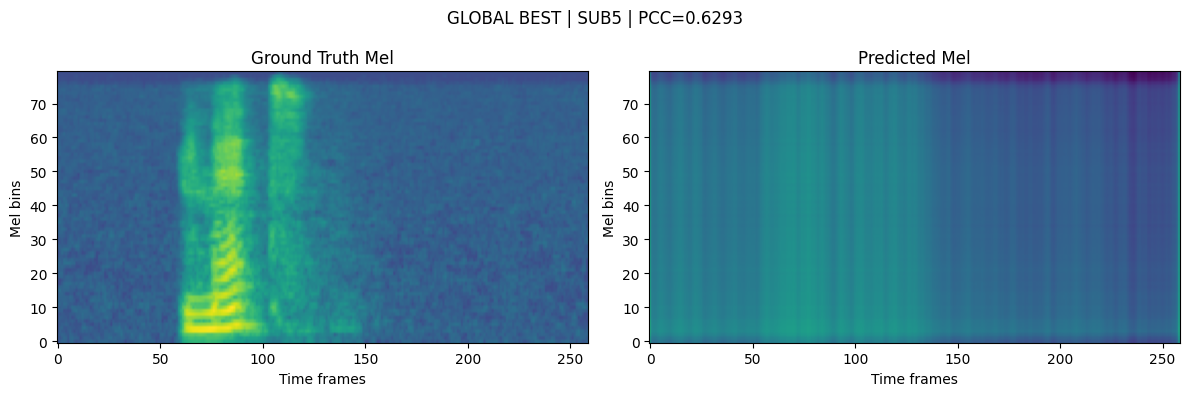

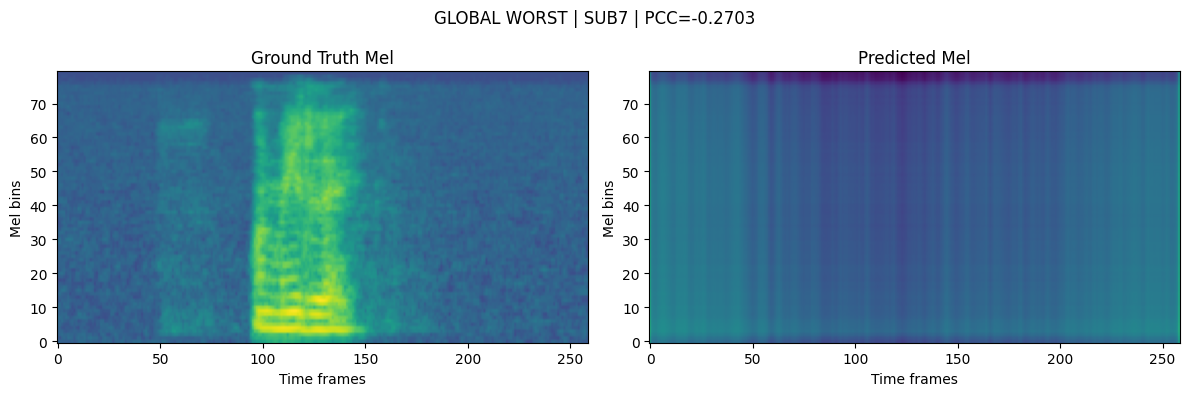


💾 Saved: GLOBAL_best_*.npy and GLOBAL_worst_*.npy


In [10]:
# ============================================================
# STEP 8: Visualize Best & Worst Samples
# ============================================================
import matplotlib.pyplot as plt

def plot_mel_pair(pred_mel, true_mel, title="Mel Comparison"):
    vmin = min(true_mel.min(), pred_mel.min())
    vmax = max(true_mel.max(), pred_mel.max())
    plt.figure(figsize=(12, 4))
    plt.suptitle(title)
    plt.subplot(1, 2, 1)
    plt.imshow(true_mel, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Ground Truth Mel")
    plt.xlabel("Time frames"); plt.ylabel("Mel bins")
    plt.subplot(1, 2, 2)
    plt.imshow(pred_mel, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Predicted Mel")
    plt.xlabel("Time frames"); plt.ylabel("Mel bins")
    plt.tight_layout()
    plt.show()

# Find global best and worst
best  = {"pcc": -1e9, "pred": None, "true": None,
         "sub": None, "batch": None, "i": None, "global_idx": None}
worst = {"pcc":  1e9, "pred": None, "true": None,
         "sub": None, "batch": None, "i": None, "global_idx": None}

model.eval()
global_counter = 0

with torch.no_grad():
    for b, (xb, yb, mask, sid) in enumerate(test_loader):
        xb   = xb.to(device)
        yb   = yb.to(device)
        mask = mask.to(device)
        sid  = sid.to(device)

        yp = model(xb, mask, sid)

        yp_np  = yp.cpu().numpy()
        yb_np  = yb.cpu().numpy()
        sid_np = sid.cpu().numpy()

        for i in range(xb.size(0)):
            pred_i    = yp_np[i]
            true_i    = yb_np[i]
            pcc_i     = pearson_corr_np(pred_i, true_i)
            subj_name = idx2sub[int(sid_np[i])]

            if pcc_i > best["pcc"]:
                best.update({"pcc": pcc_i, "pred": pred_i, "true": true_i,
                             "sub": subj_name, "batch": b, "i": i,
                             "global_idx": global_counter})
            if pcc_i < worst["pcc"]:
                worst.update({"pcc": pcc_i, "pred": pred_i, "true": true_i,
                              "sub": subj_name, "batch": b, "i": i,
                              "global_idx": global_counter})
            global_counter += 1

print(f"TEST samples total: {global_counter}")

print(f"\n✅ GLOBAL BEST")
print(f"Subject={best['sub']} | PCC={best['pcc']:.4f} | "
      f"global_idx={best['global_idx']}")

print(f"\n❌ GLOBAL WORST")
print(f"Subject={worst['sub']} | PCC={worst['pcc']:.4f} | "
      f"global_idx={worst['global_idx']}")

# Visualize
plot_mel_pair(best["pred"], best["true"],
              title=f"GLOBAL BEST | {best['sub']} | PCC={best['pcc']:.4f}")
plot_mel_pair(worst["pred"], worst["true"],
              title=f"GLOBAL WORST | {worst['sub']} | PCC={worst['pcc']:.4f}")

# Save
np.save("GLOBAL_best_pred.npy",  best["pred"])
np.save("GLOBAL_best_true.npy",  best["true"])
np.save("GLOBAL_worst_pred.npy", worst["pred"])
np.save("GLOBAL_worst_true.npy", worst["true"])
print("\n💾 Saved: GLOBAL_best_*.npy and GLOBAL_worst_*.npy")

SUB10 samples in TEST: 11
✅ Best  SUB10 PCC = 0.4937
❌ Worst SUB10 PCC = 0.0040


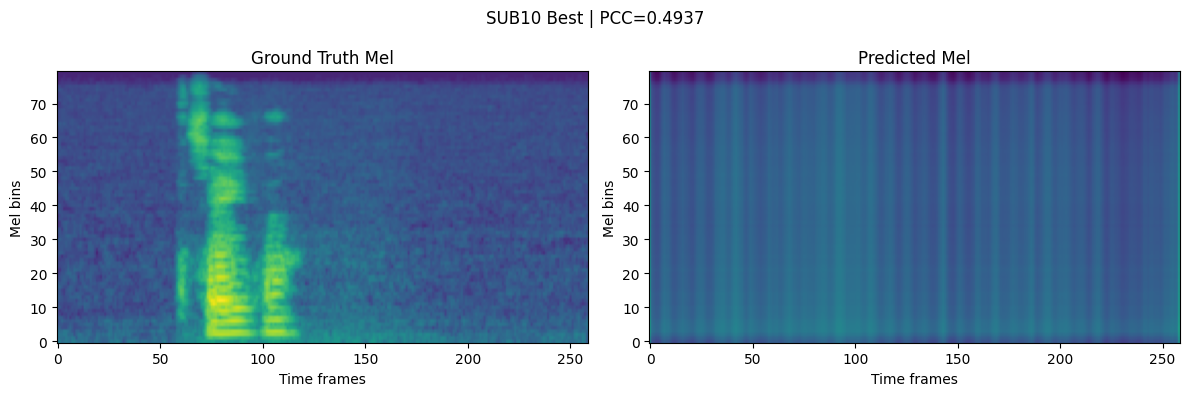

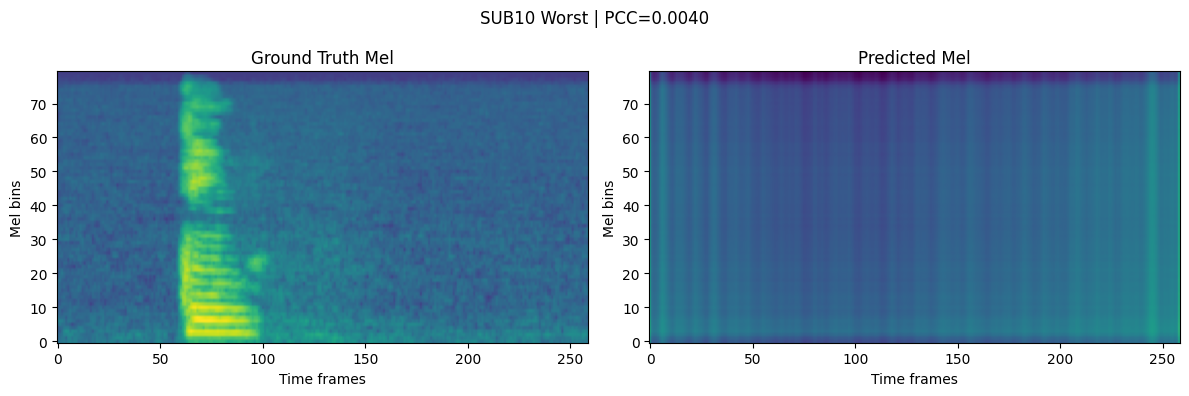

💾 Saved SUB10 best/worst predictions


In [11]:
# ============================================================
# STEP 9: Best & Worst Sample for SUB10
# ============================================================
sub10_idx = ALL_SUBJECTS.index("SUB10")

best_pcc  = -1e9
worst_pcc =  1e9
best_pred = worst_pred = None
best_true = worst_true = None

model.eval()
sub10_counter = 0

with torch.no_grad():
    for b, (xb, yb, mask, sid) in enumerate(test_loader):
        xb   = xb.to(device)
        yb   = yb.to(device)
        mask = mask.to(device)
        sid  = sid.to(device)
        yp   = model(xb, mask, sid)

        yp_np  = yp.cpu().numpy()
        yb_np  = yb.cpu().numpy()
        sid_np = sid.cpu().numpy()

        for i in range(xb.size(0)):
            if int(sid_np[i]) != sub10_idx:
                continue
            pred_i = yp_np[i]
            true_i = yb_np[i]
            pcc_i  = pearson_corr_np(pred_i, true_i)

            if pcc_i > best_pcc:
                best_pcc  = pcc_i
                best_pred = pred_i
                best_true = true_i
            if pcc_i < worst_pcc:
                worst_pcc  = pcc_i
                worst_pred = pred_i
                worst_true = true_i

            sub10_counter += 1

print(f"SUB10 samples in TEST: {sub10_counter}")
print(f"✅ Best  SUB10 PCC = {best_pcc:.4f}")
print(f"❌ Worst SUB10 PCC = {worst_pcc:.4f}")

plot_mel_pair(best_pred, best_true,
              title=f"SUB10 Best | PCC={best_pcc:.4f}")
plot_mel_pair(worst_pred, worst_true,
              title=f"SUB10 Worst | PCC={worst_pcc:.4f}")

np.save("SUB10_best_pred.npy",  best_pred)
np.save("SUB10_best_true.npy",  best_true)
np.save("SUB10_worst_pred.npy", worst_pred)
np.save("SUB10_worst_true.npy", worst_true)
print("💾 Saved SUB10 best/worst predictions")